# Terminal rendering: a mesh with no display, GPU or browser

Added in v16.33.0. A dependency-free, deterministic **software rasterizer** draws a mesh where nothing else can: an SSH session, a container, a CI log. The same pixels become Unicode block characters with terminal colours (`render_text`), an `(H, W, 4)` array (`render_image`), or a `.png`, `.txt`, `.ansi`, `.html` or `.cast` file (`snapshot`). See `doc/tui.md`.

It is a preview, not a replacement for Polyscope or the browser viewer, so each picture below sits beside what PyVista draws (or a matplotlib fallback when GL is unavailable).

In [1]:
import os
import tempfile

import matplotlib.pyplot as plt
import numpy as np
import pyvista as pv
from IPython.display import HTML, display

os.environ.setdefault('MESHIOPLUSPLUS_LOG_LEVEL', 'error')
import meshioplusplus as mp  # noqa: E402

# Head-less, static rendering (no display / live server needed).
pv.OFF_SCREEN = True
pv.set_jupyter_backend('static')
TMP = tempfile.mkdtemp()


def to_grid(mesh):
    '''A PyVista grid of a meshio++ mesh, through a temporary .vtu.'''
    target = os.path.join(TMP, 'render.vtu')
    mp.write(target, mesh)
    return pv.read(target)


def pyvista_panel(mesh, ax, title, **kwargs):
    '''Draw a mesh with PyVista into a matplotlib axis; a scatter of its points when GL is unavailable.'''
    try:
        pl = pv.Plotter(off_screen=True, window_size=(640, 480))
        pl.add_mesh(to_grid(mesh), **kwargs)
        pl.view_vector((1, 1, 0.8), viewup=(0, 0, 1))
        pl.reset_camera()
        ax.imshow(pl.screenshot(return_img=True))
        pl.close()
    except Exception as exc:  # pragma: no cover - head-less GL fallback
        print('PyVista render skipped:', exc)
        p = np.asarray(mesh.points)
        ax.scatter(p[:, 0], p[:, 1], s=1)
    ax.set_title(title, fontsize=10)
    ax.axis('off')


EXAMPLE = os.path.join(os.path.dirname(os.getcwd()), 'example.msh')
part = mp.read(EXAMPLE)
volume = mp.Mesh(part.points, [c for c in part.cells if c.type == 'tetra'])
print('tetra:', len(volume.cells[0].data))

tetra: 235014


## A picture as an array

`render_image` returns an `(H, W, 4)` uint8 array, so it goes straight into matplotlib. A volume mesh is drawn through its boundary skin; the depth buffer resolves visibility per pixel (the painter's algorithm of the SVG writer sorts whole faces, so intersecting faces come out wrong). `return_info=True` also gives the cell drawn at each pixel.

(480, 640, 4) uint8 cells visible: 22992


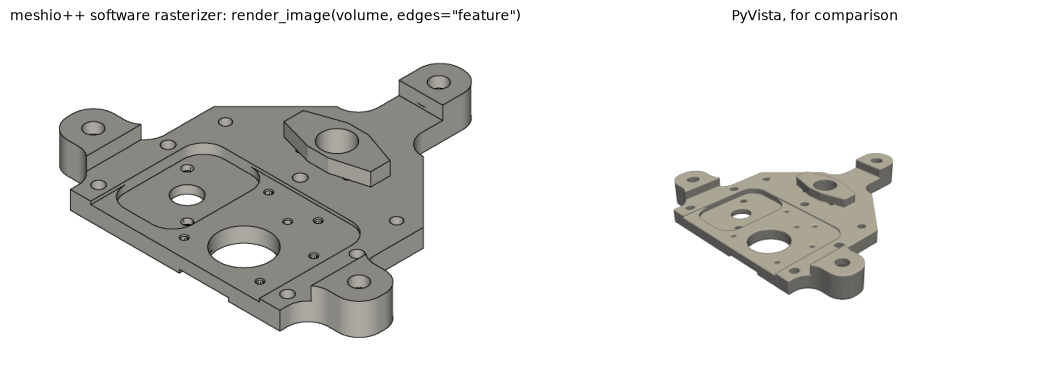

In [2]:
image, info = mp.render_image(volume, 640, 480, supersample=2, edges='feature',
                              background=(255, 255, 255, 255), return_info=True)
print(image.shape, image.dtype, 'cells visible:', len(np.unique(info['cell_ids'])) - 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
axes[0].imshow(image)
axes[0].set_title('meshio++ software rasterizer: render_image(volume, edges="feature")', fontsize=10)
axes[0].axis('off')
pyvista_panel(volume, axes[1], 'PyVista, for comparison', color='#c8c5bd', show_edges=False, smooth_shading=True)
plt.show()

## Camera, shading and edges

Every option is a keyword argument (`edges="all"` draws every element edge, which suits a coarse mesh; this one has 58,000 skin faces, so the feature edges are shown) of `render_image`, `render_text` and `snapshot`, and a flag of both CLIs. The camera is a named `view` (the side it sits on) or an azimuth and elevation; `projection="perspective"` adds a pinhole; `shading` is `none`, `flat` or `smooth` (normals from `compute_normals`, split at `split_angle`).

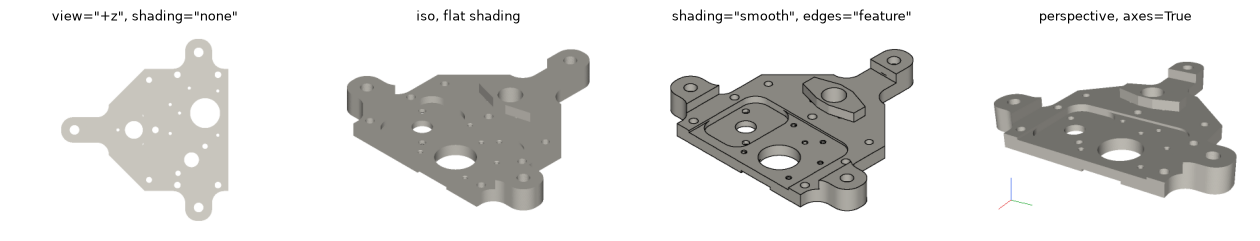

In [3]:
variants = [
    ('view="+z", shading="none"', dict(view='+z', shading='none')),
    ('iso, flat shading', dict()),
    ('shading="smooth", edges="feature"', dict(shading='smooth', edges='feature')),
    ('perspective, axes=True', dict(projection='perspective', axes=True, azimuth=30, elevation=25)),
]
fig, axes = plt.subplots(1, 4, figsize=(16, 3.6))
for ax, (title, opts) in zip(axes, variants):
    ax.imshow(mp.render_image(volume, 400, 300, supersample=2, background=(255, 255, 255, 255), **opts))
    ax.set_title(title, fontsize=9)
    ax.axis('off')
plt.show()

## Colouring by data

`color_by` follows the SVG writer's rules (point data first, then cell data; point data averaged over a face's corners; an automatic range over the drawn faces) and takes the same `component`, `cmap`, `vmin`, `vmax`, `nan_color` and `colorbar`. The colormaps are `viridis`, `coolwarm`, `turbo`, `magma`, `inferno`, `plasma`, `grey` and a reversed `_r` of each.

['quality:aspect_ratio', 'quality:degenerate', 'quality:inverted', 'quality:max_angle', 'quality:max_dihedral', 'quality:min_angle', 'quality:min_dihedral', 'quality:scaled_jacobian', 'quality:skewness', 'quality:volume', 'quality:warpage']


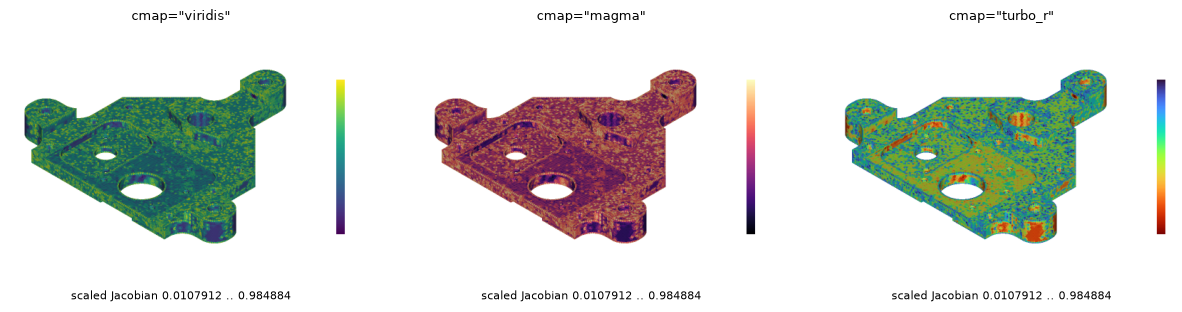

In [4]:
quality = mp.attach_quality(volume)
names = [k for k in quality.cell_data if k.startswith('quality:')]
print(names)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, cmap in zip(axes, ['viridis', 'magma', 'turbo_r']):
    img, info = mp.render_image(quality, 480, 360, supersample=2, color_by='quality:scaled_jacobian',
                                cmap=cmap, colorbar=True, background=(255, 255, 255, 255), return_info=True)
    ax.imshow(img)
    ax.set_title(f'cmap="{cmap}"', fontsize=9)
    ax.set_xlabel('scaled Jacobian ' + info['notes'][0].split(': ')[1].split(' (')[0], fontsize=8)
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
plt.show()

## The terminal form

`render_text` returns the string a terminal prints; `format="html"` returns a self-contained page whose `<pre>` holds the same cells, which is how the terminal output is embedded below. A cell holds one character in two colours, so each encoding splits a cell into a grid of pixels (`halfblock` 1x2, `quadrant` 2x2, `sextant` 2x3, `braille` 2x4, `ascii` 1x1) and picks the two-colour split with the least error.

In [5]:
for encoding in ['halfblock', 'braille']:
    page = mp.render_text(quality, cols=64, rows=20, encoding=encoding, format='html',
                          color_by='quality:scaled_jacobian', cmap='plasma', view='+z')
    print(encoding)
    display(HTML(page))

halfblock


braille


In [6]:
# The same call for a real terminal: ANSI colour escapes, or glyphs only with color_depth='mono'.
text = mp.render_text(volume, cols=48, rows=14, color_depth='mono', encoding='braille', view='+z')
print(text)

⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⣀⣀⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀
⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⢰⣿⠉⣿⡆⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀
⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⣀⣀⣀⣀⣀⣼⣿⣿⣿⣧⣀⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀
⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⣠⣾⣋⣿⣿⣿⣶⣿⣿⣿⣿⣷⣼⡇⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀
⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⣠⣾⣿⣿⣿⣿⣿⣿⣿⣿⣾⡿⠿⣿⣽⡇⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀
⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⢀⣾⣿⣿⣿⣿⣿⣿⣿⣿⡿⣿⡏⠀⠀⠀⢻⡇⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀
⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⢠⡶⠿⣿⣿⣿⣿⣿⣿⡟⠛⢻⣿⠿⣿⣿⣿⣿⣧⣀⣀⣠⣾⡇⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀
⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠘⠷⣶⣿⣿⣿⣿⣿⣿⣧⣤⣼⣿⣶⣿⣿⣿⣿⣿⣿⣿⣿⣽⡇⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀
⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⢿⣿⣿⣿⣿⣿⣿⣿⣿⣿⡿⠛⢿⣾⣿⣿⡇⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀
⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠙⢿⣿⣿⣿⣿⣿⣿⡿⣧⣤⣼⣿⣿⣿⡇⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀
⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠙⢿⣍⣿⣿⣿⠷⣿⣿⣿⣿⡿⢻⡇⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀
⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠉⠉⠉⠉⠉⢻⣿⣿⣿⡟⠉⠁⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀
⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠸⣿⣀⣿⠇⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀
⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠉⠉⠁⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀



## Files: PNG, HTML and an asciinema orbit

`snapshot` picks the form from the extension. The PNG needs no dependency (stored deflate blocks, the same bytes on every platform), a `.cast` records a reproducible orbit timed by frame index, and `screenshot()` falls back to the same rasterizer when Polyscope is not installed.

614833 bytes PNG; 6 cast frames


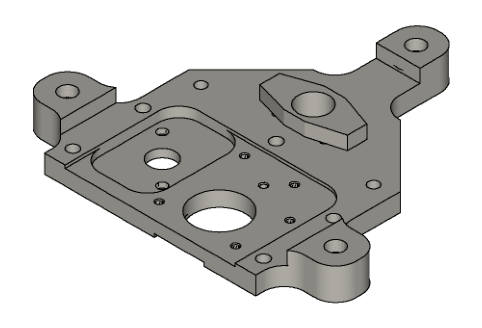

In [7]:
png = mp.snapshot(volume, os.path.join(TMP, 'part.png'), width=480, height=320, edges='feature', supersample=2)
cast = mp.snapshot(volume, os.path.join(TMP, 'orbit.cast'), cols=40, rows=12, cast_frames=6, cast_fps=3.0)
print(os.path.getsize(png), 'bytes PNG;', open(cast).read().count(chr(10)) - 1, 'cast frames')
plt.figure(figsize=(6, 4))
plt.imshow(plt.imread(png))
plt.axis('off')
plt.show()